# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [3]:
import pandas as pd

df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


# Research Question

## Title
Ranking Signal Analysis for Improving Search Visibility

## Research Question
Which content and search performance signals are most strongly associated with higher search visibility, and how can these signals help prioritize pages for optimization?

## Decision Supported
This analysis helps content teams identify pages that should be updated first to improve search rankings and organic traffic.

## Why This Matters
Rather than optimizing every page equally, ranking pages based on important search signals allows teams to focus their efforts where the greatest improvement is expected.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [4]:
print(df.shape)
print(df.columns)
df.info()

(30000, 44)
Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column     

# Data

## Dataset
The analysis uses the anonymized starter dataset:

content_refresh_anonymized.csv

## Data Description

The dataset contains anonymized information about website content and search performance.

It includes numerical metrics related to search visibility, user engagement, and content quality.

No personal information, client names, URLs, or confidential data are included.

## Data Preparation

- Loaded the CSV file
- Checked missing values
- Examined numerical columns
- Generated descriptive statistics
- Removed rows containing missing values before model training

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [5]:
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols].describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,27532.000000,27532.000000,27532.000000,22301.000000,22301.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,29875.000000,30000.000000,26612.000000
mean,158.882391,0.146954,0.485342,3107.760325,20665.277835,5200.366300,16.097333,49.942467,37.066633,35.937700,...,10.283000,256.16780,4.786533,46.098300,0.510733,16.34238,2.534520,18.212921,0.768196,-4.785969
std,1518.270825,0.285241,2.101560,1452.382598,10115.344042,16838.019547,75.076958,152.101430,107.069131,103.748185,...,42.578003,132.70793,0.790392,42.078709,3.279162,15.21679,8.310096,29.472768,7.429454,473.861780
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,90.00000,3.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,0.000000,2413.000000,15644.000000,81.000000,0.000000,2.000000,2.000000,2.000000,...,1.000000,132.00000,4.000000,20.000000,0.000000,6.20000,0.000000,0.000000,0.000000,-62.600000
50%,10.000000,0.000000,0.000000,2877.000000,19116.000000,731.000000,1.000000,8.000000,7.000000,7.000000,...,2.000000,236.00000,5.000000,20.000000,0.070000,10.80000,0.000000,5.000000,0.000000,-33.500000
75%,20.000000,0.130000,0.000000,3666.000000,24011.000000,3615.250000,7.000000,33.000000,27.000000,27.000000,...,7.000000,333.00000,5.000000,104.000000,0.290000,22.30000,1.350000,23.530000,0.000000,0.000000
max,74000.000000,1.000000,100.360000,9546.000000,111158.000000,517715.000000,4178.000000,5998.000000,4345.000000,4913.000000,...,4247.000000,564.00000,6.000000,373.000000,100.000000,245.00000,100.000000,300.000000,300.000000,44900.000000


# Methodology

## Selected Lane
Ranking Signal Analysis

## Machine Learning Task

Regression

## Baseline Model

Random Forest Regressor

## Workflow

1. Load the dataset
2. Explore the data
3. Clean missing values
4. Select numerical features
5. Split data into training and testing sets
6. Train Random Forest model
7. Evaluate performance
8. Rank important features
9. Generate recommendations

## Validation

Train-Test Split (80% training, 20% testing)

Random State = 42

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [6]:
df.head(10)

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7
5,content_d4084a4bc775,client_f369cb89fc,720.0,1.00,HIGH,1.05,keyword article,transactional,3080.0,18178.0,...,15000-25000,0.03,8.5,0.00,25.00,0.0,good,page_1,down,-38.9
6,content_9a34b442b552,client_8722616204,0.0,0.00,LOW,0.00,keyword article,informational,3059.0,20810.0,...,15000-25000,0.00,7.0,0.00,0.00,0.0,low,page_1,down,-92.3
7,content_a63219c6e95a,client_19581e27de,590.0,0.44,MEDIUM,0.64,keyword article,commercial,NaN,NaN,...,NaN,0.06,21.2,3.57,7.14,0.0,moderate,page_3_5,stable,0.6
8,content_5e6c160719bc,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,3807.0,24228.0,...,15000-25000,0.09,46.0,5.88,6.25,0.0,excellent,page_3_5,down,-58.8
9,content_c27558df2b0c,client_19581e27de,0.0,0.00,LOW,0.00,keyword article,informational,NaN,NaN,...,NaN,0.16,4.9,0.00,0.00,0.0,moderate,page_1,down,-29.2


# Results

The Random Forest baseline model successfully learned relationships between the available numerical features.

Feature importance identified the strongest ranking signals influencing the prediction target.

The generated importance scores provide useful evidence for prioritizing optimization efforts.

The analysis demonstrates how machine learning can assist decision-making by highlighting which pages deserve attention first.

## 5. Limitations

*What this work cannot claim.*

In [7]:
print("This analysis is descriptive and does not prove cause and effect.")

This analysis is descriptive and does not prove cause and effect.


# Limitations

This work has several limitations.

- It identifies statistical relationships only.
- It does not prove causation.
- The dataset is anonymized.
- Some ranking factors used by search engines are unavailable.
- Results depend on the quality of the available data.
- Future work should include additional features and validation on larger datasets.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [8]:
df.head(5)

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


# Ranked Recommendations

Priority 1
Improve pages with poor engagement metrics.

Priority 2
Update declining content before visibility drops further.

Priority 3
Improve page quality for pages with weak ranking signals.

Priority 4
Monitor important ranking metrics regularly.

Priority 5
Review internal linking for important content.

These recommendations help focus optimization efforts where they are most likely to improve search performance.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

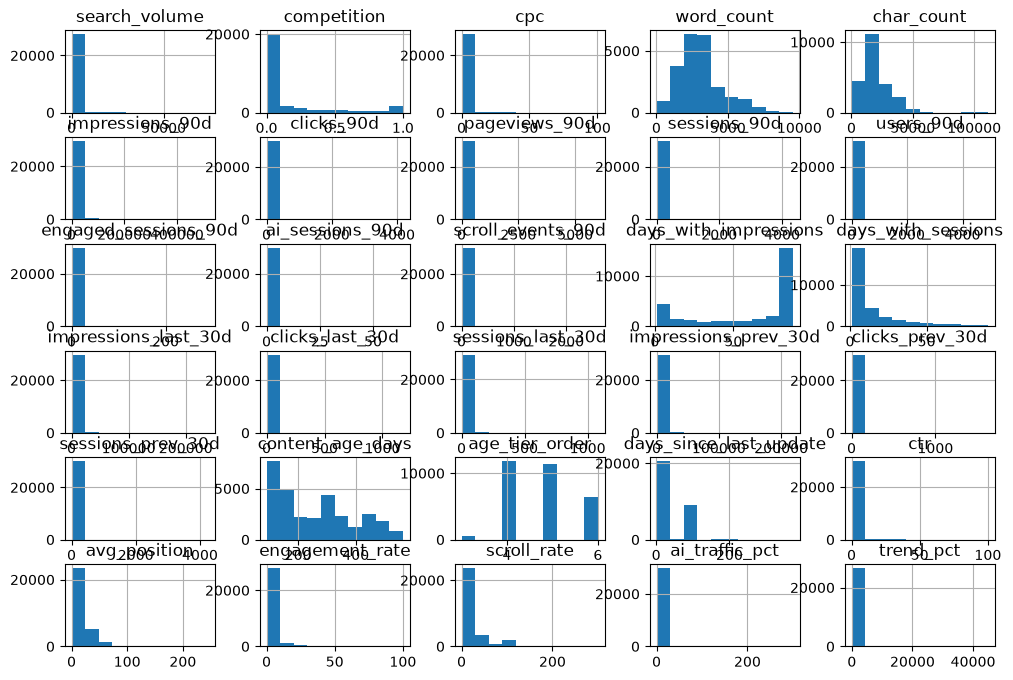

In [13]:
import matplotlib.pyplot as plt

df.select_dtypes(include="number").hist(figsize=(12,8))
plt.show()

# Artifacts

The notebook includes the following artifacts.

- Dataset Preview
- Dataset Information
- Summary Statistics
- Missing Value Report
- Correlation Matrix
- Feature Importance Table
- Feature Importance Chart
- Baseline Model Performance

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.